# Numerical Data

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train.sample(5)

,Age,Fare,Age_imputed
85,33.0,15.8500,33.0
138,16.0,9.2167,16.0
28,NaN,7.8792,NaN
487,58.0,29.7000,58.0
691,4.0,13.4167,4.0


In [20]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [21]:
X_test.sample(5)

,Age,Fare,Age_imputed
743,24.00,16.1000,24.00
614,35.00,8.0500,35.00
305,0.92,151.5500,0.92
453,49.00,89.1042,49.00
522,NaN,7.2250,NaN


In [22]:
X_train['Age'].isnull().sum()

np.int64(148)

In [23]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([24.  ,  0.83, 42.  ,  1.  , 24.  , 20.  , 31.  , 47.  , 41.  ,
       33.  , 49.  , 26.  , 34.  , 21.  , 22.  , 52.  , 44.  ,  4.  ,
       29.  , 22.  , 44.  , 49.  , 30.  , 40.  , 21.  , 30.  , 32.  ,
       38.  , 25.  , 36.  , 19.  , 48.  , 20.  , 42.  ,  2.  , 70.5 ,
       37.  , 22.  , 39.  ,  3.  , 45.  , 27.  , 16.  , 25.  , 22.  ,
       27.  , 37.  , 26.  , 52.  , 30.  , 31.  , 23.  , 45.  , 16.  ,
        7.  , 32.  , 52.  , 24.  , 19.  , 25.  , 16.  , 36.  , 28.  ,
       16.  , 50.  , 45.  , 19.  , 17.  , 27.  , 30.  , 58.  , 11.  ,
       40.5 , 25.  , 11.  , 22.  , 71.  , 48.  , 33.  , 39.  , 19.  ,
       20.  , 28.  , 16.  , 21.  , 23.  , 17.  , 22.  , 30.  , 42.  ,
       56.  , 26.  ,  1.  , 28.  , 34.  , 27.  , 24.  , 25.  , 26.  ,
       39.  , 36.  , 21.  , 60.  , 18.  , 18.  , 23.  , 16.  , 35.  ,
       33.  , 48.  , 29.  , 23.  , 24.  , 36.  , 18.  , 19.  ,  8.  ,
       26.  , 39.  , 36.  , 48.  , 49.  , 20.  , 36.  , 36.  , 10.  ,
       25.  , 16.  ,

In [24]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum()).values

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum()).values

In [25]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,29.0
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [26]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([46.  , 39.  ,  4.  , 19.  , 33.  ,  8.  , 23.  ,  4.  ,  3.  ,
       30.5 , 32.  , 29.  , 15.  , 33.  , 31.  , 20.  ,  4.  , 30.  ,
       29.  , 25.  , 47.  , 52.  , 33.  , 39.  , 16.  , 18.  , 48.  ,
       25.  , 34.  ,  9.  , 32.  ,  0.67, 32.  , 48.  ,  0.83, 30.  ,
        2.  , 39.  , 28.  , 19.  , 13.  , 12.  , 54.  , 45.5 , 52.  ,
       35.  , 39.  , 26.  , 28.5 , 16.  , 30.  , 22.  , 57.  , 20.  ,
       38.  , 27.  , 29.  , 23.  , 33.  , 21.  , 42.  , 29.  , 47.  ,
        3.  , 24.  , 50.  , 19.  , 41.  , 46.  , 22.  , 50.  , 39.  ,
       19.  , 38.  , 31.  , 34.  , 34.  , 16.  , 16.  , 20.  , 51.  ,
       28.  , 31.  , 41.  , 64.  , 23.  , 24.  , 28.  , 44.  ,  7.  ,
       16.  , 39.  , 14.  ,  4.  , 22.  , 29.  , 19.  , 29.  , 21.  ,
       29.  , 28.  , 26.  , 40.5 , 18.  , 31.  ,  9.  , 58.  , 18.  ,
       58.  , 36.  , 18.  , 48.  , 22.  , 19.  , 45.  , 23.5 , 47.  ,
       21.  , 32.  , 28.5 , 33.  ,  2.  , 25.  , 27.  , 40.5 , 39.  ,
       18.  , 31.  ,

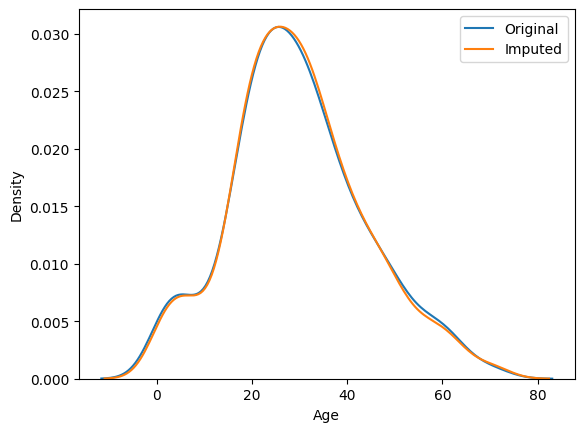

In [27]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [28]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  199.71665717516868


In [29]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,69.399930
Age,71.512440,204.349513,204.349513
Age_imputed,69.399930,204.349513,199.716657


<Axes: >

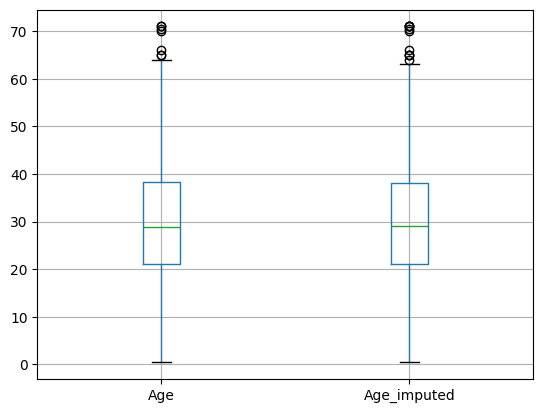

In [30]:
X_train[['Age', 'Age_imputed']].boxplot()

In [34]:
for index, observation in X_train.iterrows():
    sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

# Categorical Data